# MSML606 HW-3

### AI tools (ChatGPT, Claude) were used for general understanding and clarification of concepts (trees, stacks).

## Part I: Hash table implementation

## Problem 1. Implement a hash table.

In [7]:
import time
import random
import matplotlib.pyplot as plt

class HashMap:
    def __init__(self, size=101):
        self.size = size
        self.table = []
        self.count = 0
        self.hash_method = "division"
        for _ in range(size):
            self.table.append([])   # each is a list

    def _key_to_int(self, key):
        # convert key into a number
        if type(key) == int:
            return abs(key)
        elif type(key) == str:
            total = 0
            for ch in key:
                total = total + ord(ch)
            return total
        else:
            # edge case
            text = str(key)
            total = 0
            for ch in text:
                total = total + ord(ch)
            return total

    # retrieve value
    def search(self, key):
        index = self._hash(key, self.hash_method)
        chain = self.table[index]
        for pair in chain:
            if pair[0] == key:
                return pair[1]
        return None

    # insert into the hash table
    def insert(self, key, value):
        index = self._hash(key, self.hash_method)
        chain = self.table[index]
        # update if key already exists
        for i in range(len(chain)):
            if chain[i][0] == key:
                chain[i] = (key, value)
                return
        chain.append((key, value))
        self.count += 1

    # remove the key value pair from table
    def delete(self, key):
        index = self._hash(key, self.hash_method)
        chain = self.table[index]

        for i in range(len(chain)):
            if chain[i][0] == key:
                del chain[i]
                self.count -= 1
                return True

        return False

    def dynamicResizing(self):
        pass

    # hashing methods
    def _hash(self, key, method="division"):
        num = self._key_to_int(key)

        # division
        if method == "division":
            return num % self.size

        # multiplication
        elif method == "multiplication":
            a = 0.618
            frac = (num * a) % 1
            return int(self.size * frac)

        # default case
        return num % self.size

    def load_factor(self):
        return self.count / self.size

    def average_chain_length(self):
        total = 0
        for chain in self.table:
            total += len(chain)
        return total / self.size

    def max_chain_length(self):
        longest = 0
        for chain in self.table:
            if len(chain) > longest:
                longest = len(chain)
        return longest



## Problem 2. Performance Analysis

Search apple: 10
Search banana: 20
After delete banana: None
Method: division | Size: 101 | Load Factor: 0.25 | Success Time: 3.918000220437534e-07 | Fail Time: 3.049199949600734e-07
Method: division | Size: 101 | Load Factor: 0.5 | Success Time: 3.3455999073339624e-07 | Fail Time: 2.984999991895165e-07
Method: division | Size: 101 | Load Factor: 0.75 | Success Time: 3.331333330910032e-07 | Fail Time: 2.960666703681151e-07
Method: division | Size: 101 | Load Factor: 1.0 | Success Time: 3.378200017323252e-07 | Fail Time: 2.9656000151589977e-07
Method: division | Size: 101 | Load Factor: 1.25 | Success Time: 3.480099985608831e-07 | Fail Time: 3.121699955954682e-07


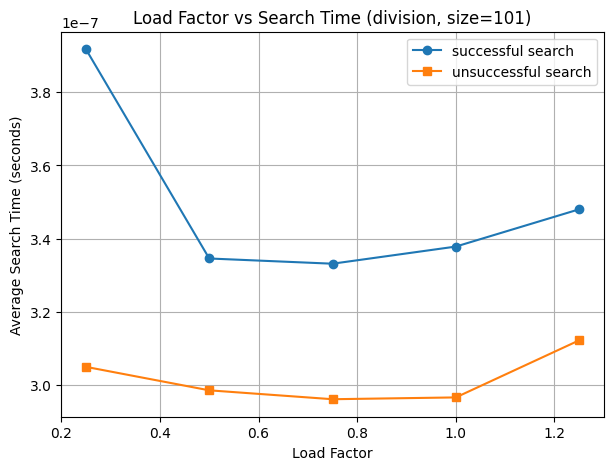

Method: division | Size: 503 | Load Factor: 0.25 | Success Time: 3.5956999454356266e-07 | Fail Time: 3.247799941163976e-07
Method: division | Size: 503 | Load Factor: 0.5 | Success Time: 3.5207999644626397e-07 | Fail Time: 3.114300034212647e-07
Method: division | Size: 503 | Load Factor: 0.75 | Success Time: 3.630900027928874e-07 | Fail Time: 3.3444000109739134e-07
Method: division | Size: 503 | Load Factor: 1.0 | Success Time: 4.1356999645358885e-07 | Fail Time: 3.4570999559946356e-07
Method: division | Size: 503 | Load Factor: 1.25 | Success Time: 3.8363999919965864e-07 | Fail Time: 3.4124000194424296e-07


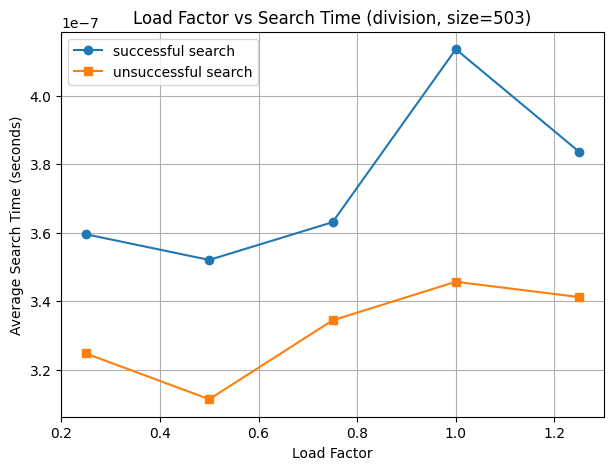

Method: division | Size: 1009 | Load Factor: 0.25 | Success Time: 2.9936500050098404e-06 | Fail Time: 9.733699971548048e-07
Method: division | Size: 1009 | Load Factor: 0.5 | Success Time: 7.3154500023520085e-06 | Fail Time: 8.264699954452226e-07
Method: division | Size: 1009 | Load Factor: 0.75 | Success Time: 7.271400045283372e-07 | Fail Time: 6.78489996062126e-07
Method: division | Size: 1009 | Load Factor: 1.0 | Success Time: 7.285900028364268e-07 | Fail Time: 7.126800028345314e-07
Method: division | Size: 1009 | Load Factor: 1.25 | Success Time: 1.0107700018124889e-06 | Fail Time: 7.841299975552829e-07


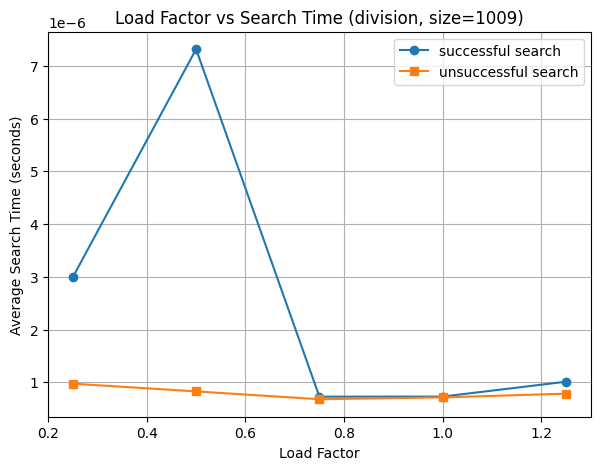

Method: multiplication | Size: 101 | Load Factor: 0.25 | Success Time: 1.0850000035134145e-06 | Fail Time: 2.256560001114849e-06
Method: multiplication | Size: 101 | Load Factor: 0.5 | Success Time: 1.0420400030852762e-06 | Fail Time: 1.0028799988504033e-06
Method: multiplication | Size: 101 | Load Factor: 0.75 | Success Time: 1.0403999961757411e-06 | Fail Time: 1.0093866634027411e-06
Method: multiplication | Size: 101 | Load Factor: 1.0 | Success Time: 1.4030760003151954e-05 | Fail Time: 1.0726399978011613e-06
Method: multiplication | Size: 101 | Load Factor: 1.25 | Success Time: 1.0595200001262129e-06 | Fail Time: 1.0296099935658275e-06


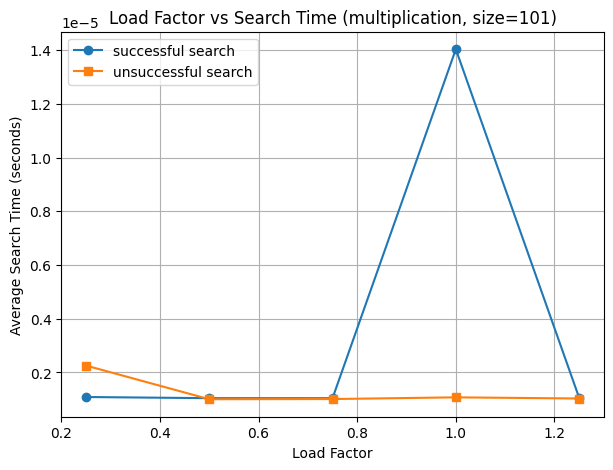

Method: multiplication | Size: 503 | Load Factor: 0.25 | Success Time: 1.0621100045682397e-06 | Fail Time: 1.0109399954671972e-06
Method: multiplication | Size: 503 | Load Factor: 0.5 | Success Time: 1.1697399986587697e-06 | Fail Time: 1.0337900039303348e-06
Method: multiplication | Size: 503 | Load Factor: 0.75 | Success Time: 1.0557299992797197e-06 | Fail Time: 9.819499973673373e-07
Method: multiplication | Size: 503 | Load Factor: 1.0 | Success Time: 1.1245699988648994e-06 | Fail Time: 1.2334499933785993e-06
Method: multiplication | Size: 503 | Load Factor: 1.25 | Success Time: 9.837099969445263e-07 | Fail Time: 9.51570000324864e-07


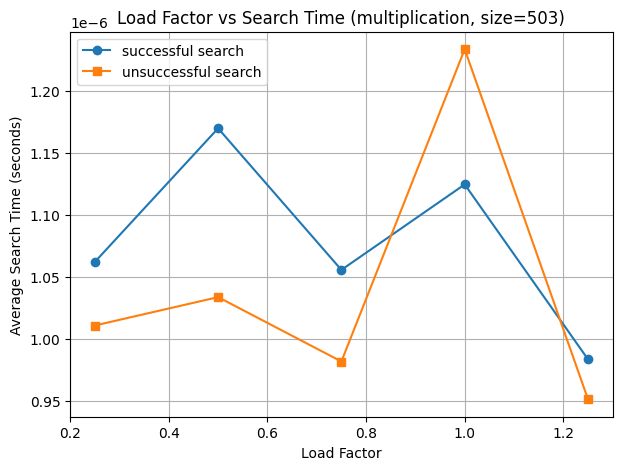

Method: multiplication | Size: 1009 | Load Factor: 0.25 | Success Time: 1.1250100033066702e-06 | Fail Time: 1.039970002238988e-06
Method: multiplication | Size: 1009 | Load Factor: 0.5 | Success Time: 1.762510000844486e-06 | Fail Time: 2.2781500047130975e-06
Method: multiplication | Size: 1009 | Load Factor: 0.75 | Success Time: 1.0960600047837943e-06 | Fail Time: 1.1910299963346916e-06
Method: multiplication | Size: 1009 | Load Factor: 1.0 | Success Time: 1.0573300005489726e-06 | Fail Time: 1.04218000160472e-06
Method: multiplication | Size: 1009 | Load Factor: 1.25 | Success Time: 1.4444299995375332e-06 | Fail Time: 1.2163500014139572e-06


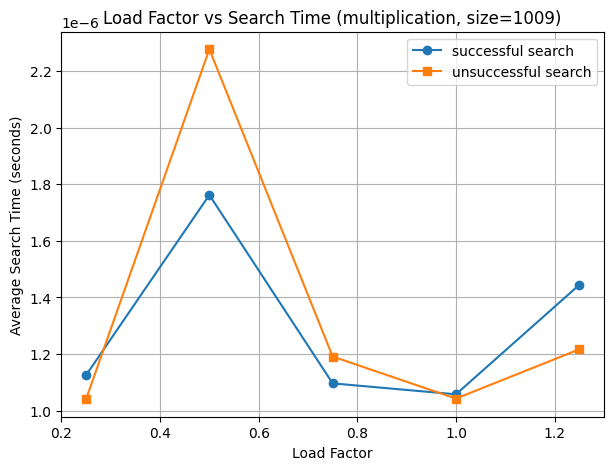


Distribution: uniform
Method: division
Successful search time: 5.951999992248602e-07
Unsuccessful search time: 5.710099958378123e-07
Average chain length: 0.7455268389662028
Maximum chain length: 4

Distribution: skewed
Method: division
Successful search time: 6.318799933069386e-07
Unsuccessful search time: 6.899199979670812e-07
Average chain length: 0.3518886679920477
Maximum chain length: 3

Distribution: sequential
Method: division
Successful search time: 5.723699996451614e-07
Unsuccessful search time: 4.7665999773016667e-07
Average chain length: 0.7495029821073559
Maximum chain length: 1


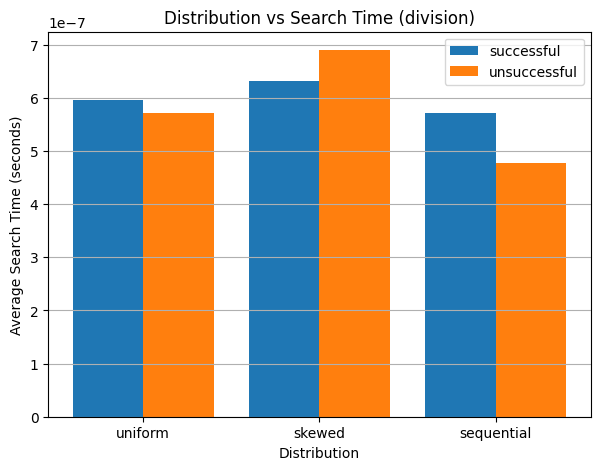

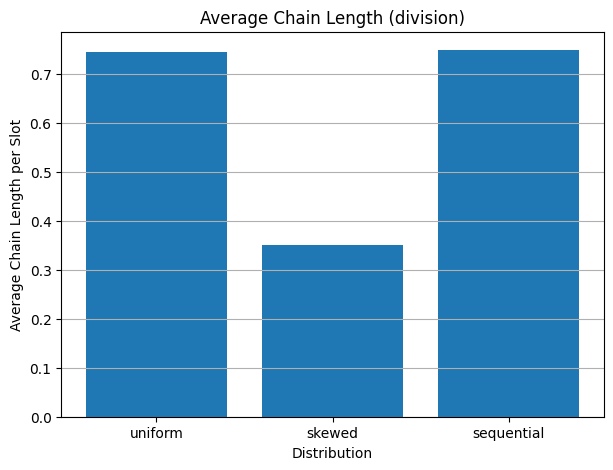

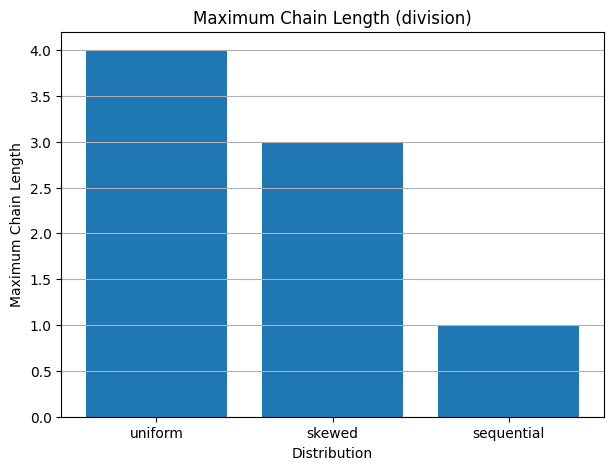


Distribution: uniform
Method: multiplication
Successful search time: 1.1350000022503081e-06
Unsuccessful search time: 1.1154000003443798e-06
Average chain length: 0.7495029821073559
Maximum chain length: 4

Distribution: skewed
Method: multiplication
Successful search time: 1.2656400031119119e-06
Unsuccessful search time: 9.981000039260835e-07
Average chain length: 0.33399602385685884
Maximum chain length: 3

Distribution: sequential
Method: multiplication
Successful search time: 1.2412999967637006e-06
Unsuccessful search time: 1.1836099929496413e-06
Average chain length: 0.7495029821073559
Maximum chain length: 1


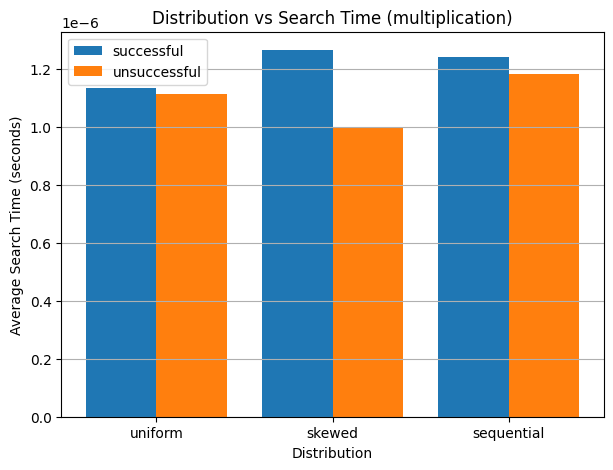

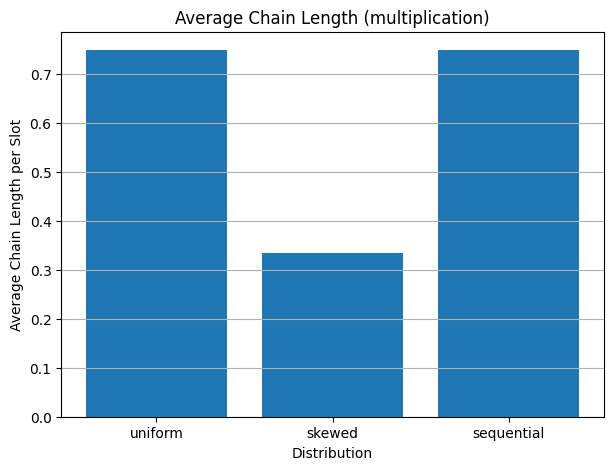

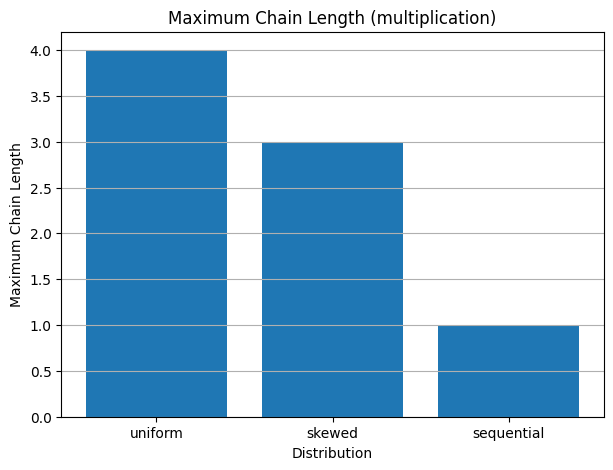

In [8]:
def generate_keys(distribution, n):
    keys = []

    if distribution == "uniform":
        for _ in range(n):
            keys.append(random.randint(1, 1000000))

    elif distribution == "skewed":
        for _ in range(n):
            if random.random() < 0.8:
                keys.append(random.randint(1, 100))
            else:
                keys.append(random.randint(101, 1000000))

    elif distribution == "sequential":
        for i in range(n):
            keys.append(i + 1)

    return keys


def measure_search_time(hashmap, keys):
    start = time.perf_counter()

    for key in keys:
        hashmap.search(key)

    end = time.perf_counter()

    if len(keys) == 0:
        return 0

    return (end - start) / len(keys)


def run_experiments():

    table_sizes = [101, 503, 1009]
    load_factors = [0.25, 0.50, 0.75, 1.0, 1.25]
    methods = ["division", "multiplication"]
    # Experiment 1
    # Load factor vs search time
    for method in methods:
        for size in table_sizes:
            good_times = []
            bad_times = []

            for lf in load_factors:
                h = HashMap(size)
                h.hash_method = method

                n = int(size * lf)
                keys = generate_keys("uniform", n)

                for key in keys:
                    h.insert(key, key * 10)

                # successful search
                if len(keys) > 100:
                    good_keys = random.sample(keys, 100)
                else:
                    good_keys = keys[:]

                # unsuccessful search
                bad_keys = []
                while len(bad_keys) < len(good_keys):
                    x = random.randint(2000000, 3000000)
                    bad_keys.append(x)

                t_good = measure_search_time(h, good_keys)
                t_bad = measure_search_time(h, bad_keys)

                good_times.append(t_good)
                bad_times.append(t_bad)

                print("Method:", method,
                      "| Size:", size,
                      "| Load Factor:", round(lf, 2),
                      "| Success Time:", t_good,
                      "| Fail Time:", t_bad)

            plt.figure(figsize=(7, 5))
            plt.plot(load_factors, good_times, marker='o', label='successful search')
            plt.plot(load_factors, bad_times, marker='s', label='unsuccessful search')
            plt.xlabel("Load Factor")
            plt.ylabel("Average Search Time (seconds)")
            plt.title("Load Factor vs Search Time (" + method + ", size=" + str(size) + ")")
            plt.legend()
            plt.grid(True)
            plt.show()

    # Experiment 2
    # Key distribution comparisons
    fixed_size = 503
    fixed_load_factor = 0.75
    n = int(fixed_size * fixed_load_factor)

    distributions = ["uniform", "skewed", "sequential"]

    for method in methods:
        success_result = []
        fail_result = []
        avg_chain_result = []
        max_chain_result = []

        for dist in distributions:
            h = HashMap(fixed_size)
            h.hash_method = method

            keys = generate_keys(dist, n)

            for key in keys:
                h.insert(key, key * 10)

            if len(keys) > 100:
                good_keys = random.sample(keys, 100)
            else:
                good_keys = keys[:]

            bad_keys = []
            while len(bad_keys) < len(good_keys):
                x = random.randint(2000000, 3000000)
                bad_keys.append(x)

            t_good = measure_search_time(h, good_keys)
            t_bad = measure_search_time(h, bad_keys)

            success_result.append(t_good)
            fail_result.append(t_bad)
            avg_chain_result.append(h.average_chain_length())
            max_chain_result.append(h.max_chain_length())

            print("\nDistribution:", dist)
            print("Method:", method)
            print("Successful search time:", t_good)
            print("Unsuccessful search time:", t_bad)
            print("Average chain length:", h.average_chain_length())
            print("Maximum chain length:", h.max_chain_length())

        # plot search time for distributions
        x = range(len(distributions))

        plt.figure(figsize=(7, 5))
        plt.bar([i - 0.2 for i in x], success_result, width=0.4, label='successful')
        plt.bar([i + 0.2 for i in x], fail_result, width=0.4, label='unsuccessful')
        plt.xticks(list(x), distributions)
        plt.xlabel("Distribution")
        plt.ylabel("Average Search Time (seconds)")
        plt.title("Distribution vs Search Time (" + method + ")")
        plt.legend()
        plt.grid(True, axis='y')
        plt.show()

        # plot chain lengths
        plt.figure(figsize=(7, 5))
        plt.bar(distributions, avg_chain_result)
        plt.xlabel("Distribution")
        plt.ylabel("Average Chain Length per Slot")
        plt.title("Average Chain Length (" + method + ")")
        plt.grid(True, axis='y')
        plt.show()

        plt.figure(figsize=(7, 5))
        plt.bar(distributions, max_chain_result)
        plt.xlabel("Distribution")
        plt.ylabel("Maximum Chain Length")
        plt.title("Maximum Chain Length (" + method + ")")
        plt.grid(True, axis='y')
        plt.show()


# example test
if __name__ == "__main__":
    h = HashMap(11)
    h.hash_method = "division"

    h.insert("apple", 10)
    h.insert("banana", 20)
    h.insert("orange", 30)

    print("Search apple:", h.search("apple"))
    print("Search banana:", h.search("banana"))

    h.delete("banana")
    print("After delete banana:", h.search("banana"))

    run_experiments()